<img src="./pic/sharif-main-logo.png" alt="SUT logo" width=345 height=345 align=left class="saturate">


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Machine Learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2024<br>
<font color=3C99D size=5>
    Practical Assignment 2 - Unsupervised Learning<br>
<font color=696880 size=4>
    Assignment Supervisor: Niki Sepasian <br>
<font color=696880 size=5>
    Asemaneh Nafe


In [1]:
student_number = 401102789
full_name = 'Seyed Ali Vakilzadeh'
assert student_number and full_name is not None, 'please input your information'

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

<font color=red size=3>
notice that you can not use sklearn.decomposition and sklearn.cluster libary in this home work! you should implement pca and kmeans from scratch.

## Overview
In this assignment, you will perform PCA and K-Means clustering on credit card customer data. dataset contains information about customer’s use of credit cards. The goal is to reduce the dataset’s dimensionality using PCA and then apply clustering to segment customers. You will compare the clustering performance both before and after PCA. Additionally, you'll be asked to explain the theory and decisions behind each step.

## Data Preprocessing (15 points)
Read the dataset.CSV file and display a few samples.

In [3]:
# todo
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/ML_Practicals/HW2/Practical2/dataset.csv"
# Load the dataset
# "Attrition" is our target columm

df = pd.read_csv(file_path)
df.head(5)

Mounted at /content/drive


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Display dataset information.

In [4]:
# todo
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

Which column do you think might be the most irrelevant for PCA and clustering?
<br>
Answer:

In [5]:
#customer ID gives little information about the actual costumers data and is rather used to manage the database
# Exclude irrelevant feature
df=df.drop(columns=['CUST_ID'])

how do you handle missing data, and why did you choose this method?
<br>
Answer:


In [6]:

#Fill missing data: replace missing values with mean of known values: since not many properties have missing value, this simple method should be useful
df.fillna(df.mean(), inplace=True)

plot the correlation matrix and identify redundant features.remove them from the dataframe.

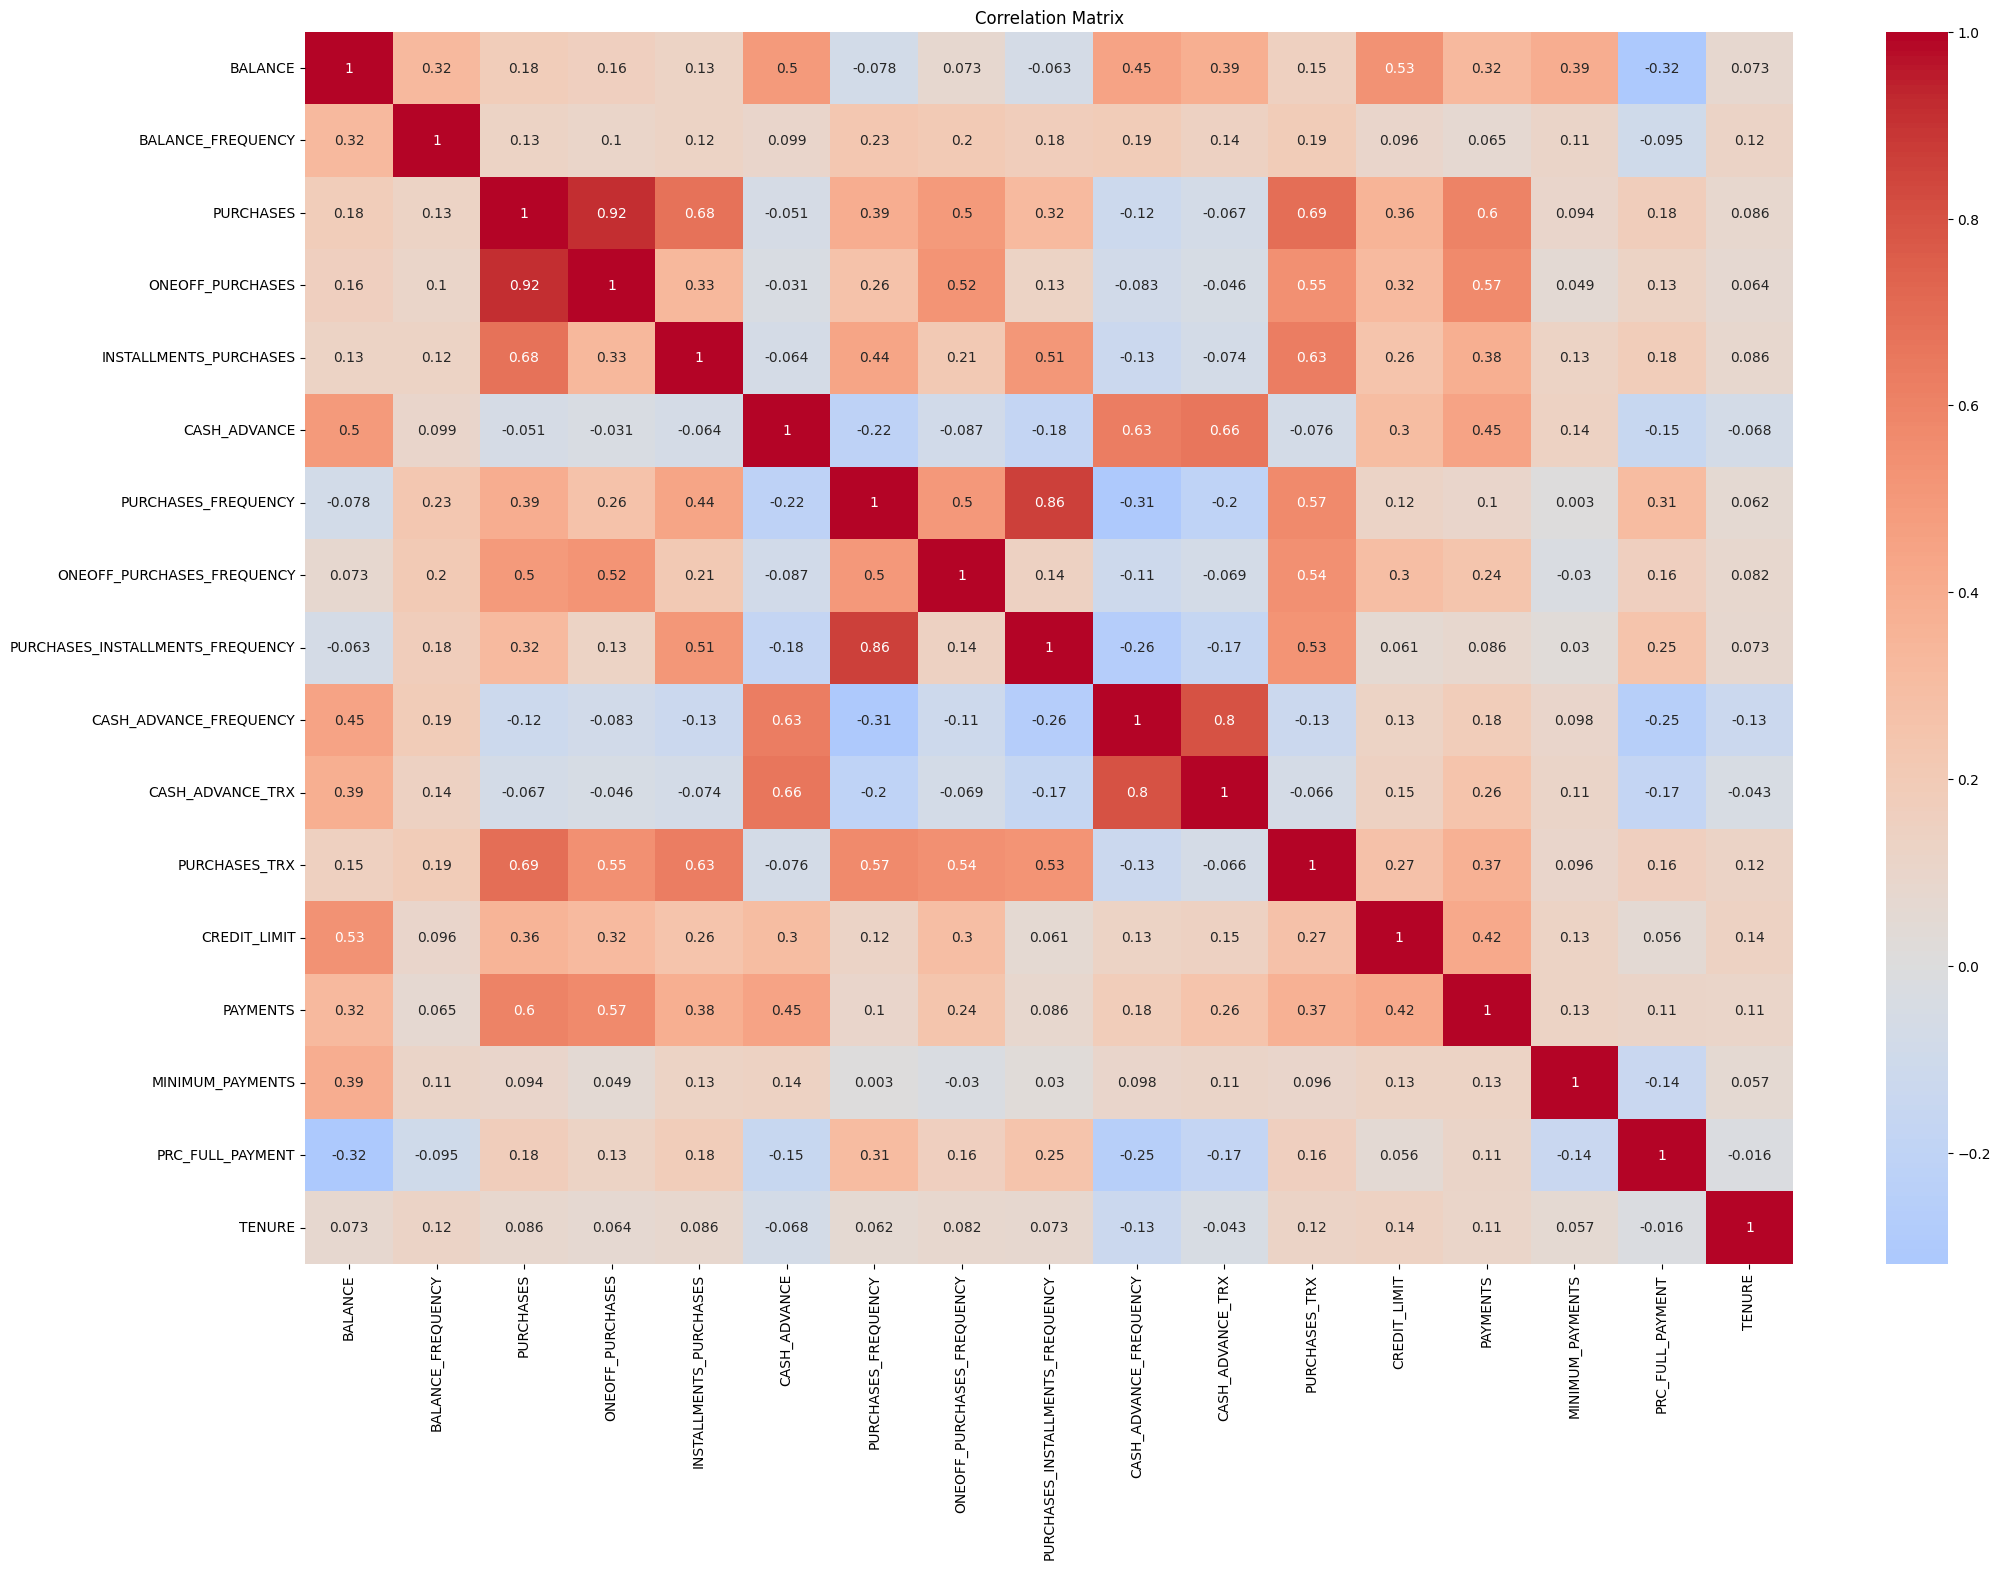

In [7]:
# Plot the correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(24, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [8]:
# Identify and remove redundant features. use 0.8 threshold.
# Calculate the correlation matrix
corr_matrix = df.corr().abs()
to_drop = []
# Find features with correlation greater than the threshold
threshold = 0.8
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for column in upper_triangle.columns:
    if any(upper_triangle[column] > threshold):
        to_drop.append(column)


# Drop redundant features
df_reduced = df.drop(columns=to_drop)
print(f"Redundant features: {', '.join(to_drop)}")

Redundant features: ONEOFF_PURCHASES, PURCHASES_INSTALLMENTS_FREQUENCY


## Standardize the Data (5 points)
Standardize the dataset using z-score normalization

In [9]:
# todo
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Why is it important to standardize the data before applying PCA?
<br>
Answer:
Since PCA aims to identify the directions (principal componenets) in which the variance is maximized, unnormalized data (such as a feature scaled in thousands) can often cause the model to orient towards them instead of capturing the true patern.

What is differnce between Normalizer and StandardScaler classes. which is better for PCA?
<br>
Answer:
normalizer transform samples to have a unit norm, and is useful when observations are done sample-wise. On the other hand, Standard Scaler will direct each feature to have a mean of 0 and a variance of 1, equalizing the contribution of each feature on our model.Since PCA is maximizing variance on principal componenents and is more feature oriented than sample-wise, we are better-off using standard scaler

## Principal Component Analysis (PCA) (35 points)
Implement PCA from scratch.

In [10]:
import numpy as np

class CustomPCA:
    def __init__(self, n_components=None):
        """
        Initialize the PCA class with the number of components to keep.
        n_components: Number of principal components to keep. If None, all components are kept.
        """
        self.n_components = n_components
        self.components = None  # To store the principal components (eigenvectors)
        self.mean = None        # To store the mean of the data (used for centering the data)
        self.explained_variance_ratio = None  # To store the explained variance ratio of the components

    def fit(self, X):
        """
        Fit the PCA model on the dataset X by calculating the eigenvalues and eigenvectors of the covariance matrix.
        X: Input data (n_samples, n_features)
        """
        self.mean=X.mean()
        X_standardized = (X - X.mean()) / X.std()

        #assuming dataset is standardized:
        cov_matrix = np.cov(X_standardized.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        self.components=eigenvectors[:, :self.n_components]
        self.explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

    def transform(self, X):
        """
        Transform the input data X into the new space using the principal components.
        X: Input data (n_samples, n_features)
        """
        X_standardized = (X - self.mean) / X.std()
        # Return the transformed data
        X_transformed = np.dot(X_standardized, self.components)
        return X_transformed

    def get_explained_variance_ratio(self):
        """
        Return the explained variance ratio of each principal component.
        """
        return self.explained_variance_ratio

    def get_components(self):
        """
        Return the principal components (eigenvectors).
        """
        return self.components

### Visualizing the Cumulative Variance

Plot the cumulative explained variance to visualize the selection of components.  How many components are needed to explain 75% of the variance?
<br>
answer:

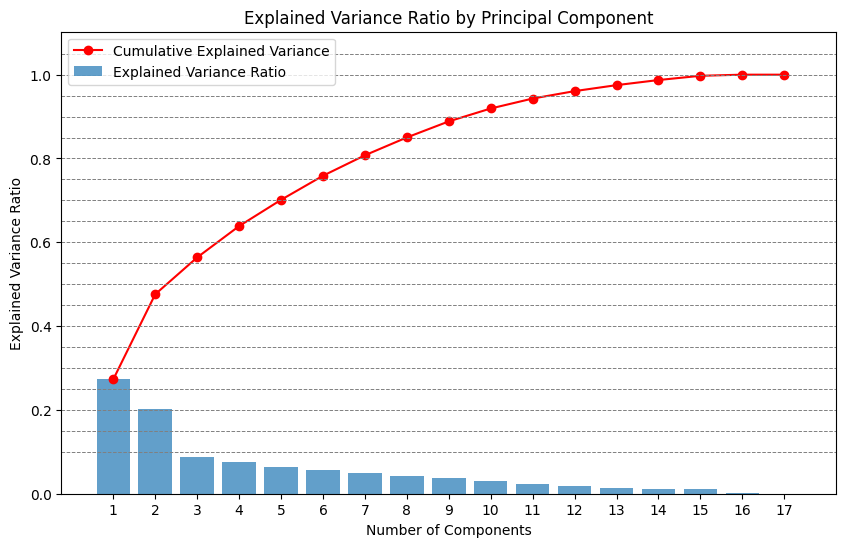

[0.27290037 0.47592029 0.56384008 0.63863983 0.70126775 0.75876986
 0.80764221 0.85021707 0.88850511 0.91930517 0.94302415 0.96076047
 0.97502539 0.98719908 0.99732898 0.99999931 1.        ]


In [11]:
# todo
PCA=CustomPCA(n_components=None)
PCA.fit(df_standardized)
explained_variance_ratio=PCA.get_explained_variance_ratio()
cumulative_variance = np.cumsum(explained_variance_ratio)



plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, label='Explained Variance Ratio')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='r', label='Cumulative Explained Variance')
for y in np.arange(0.1, 1.1, 0.05):
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.7)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend()
plt.show()




#as shown below, 6 or more principal points are needed to explain more than 75% of this data variance
print(cumulative_variance)

Build a new DataFrame with the first slected components. save it to a new CSV file named 'pca_output.csv'

In [12]:
#Build a new DataFrame with the first slected components
opt_PCA=CustomPCA(n_components=5)
opt_PCA.fit(df_standardized)
X_transformed=opt_PCA.transform(df_standardized)
df_transformed = pd.DataFrame(X_transformed, columns=[f'PC{i+1}' for i in range(5)])
print(df_transformed.head())

        PC1       PC2       PC3       PC4       PC5
0 -1.682126  1.076390 -0.488479  0.665515 -0.018224
1 -1.138231 -2.506337 -0.601179 -0.120430 -0.605769
2  0.969630  0.383499 -0.102366  1.209199  2.172463
3 -0.873579 -0.043163 -1.460085  1.151916 -0.295615
4 -1.599344  0.688542 -0.365073  0.990176  0.487012


We expect these new features to be orthogonal to each other. Check this and show the correlation between the features.

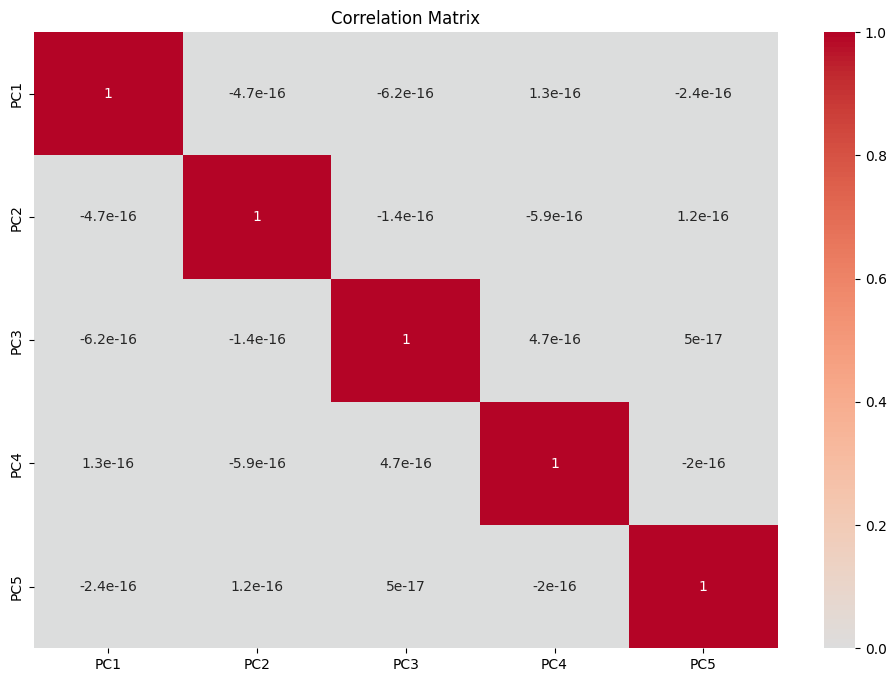

In [13]:
# todo
# Plot the correlation matrix
corr_matrix = df_transformed.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

## KMeans (45 points)
Implement kmeans from scratch.

In [14]:
import numpy as np

class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        """
        Initialize the KMeans class with the number of clusters and maximum iterations.
        n_clusters: Number of clusters to form.
        max_iter: Maximum number of iterations for convergence.
        random_state: Seed for reproducibility.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None  # To store the centroids of clusters
        self.inertia_ = None   # To store the inertia (within-cluster sum of squares)
        self.labels_ = None    # To store the label assigned to each data point (cluster assignment)

    def euclidian_distance(self, x1, x2):
      return np.linalg.norm(x1-x2)

    def fit(self, X):
        """
        Fit the KMeans model on the dataset X.
        X: Input data (n_samples, n_features)
        """
        n_samples, n_features = X.shape

        self.centroids = np.empty((self.n_clusters, n_features))

        for feature in range(n_features):
          min_value = X[:, feature].min()  # Use .iloc for DataFrame indexing
          max_value = X[:, feature].max()
          self.centroids[:, feature] = np.random.uniform(min_value, max_value, size=self.n_clusters)
        # Create an array to store the k random points
        self.labels_ = np.empty(n_samples, dtype=int)

        for i in range(self.max_iter):
            # Assign labels
            for j in range(n_samples):
                self.labels_[j] = self.find_nearest_centroid(X[j])
            # Calculate new centroids
            new_centroids = np.array([self.find_labels_new_centroid(cluster, X) for cluster in range(self.n_clusters)])

            # Check for convergence (if centroids do not change)
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids  # Update centroids
        # Calculate inertia
        self.inertia_ = self._calculate_inertia(X)
        return self

    def _calculate_inertia(self, X):
        """
        Calculate the within-cluster sum of squared distances (inertia).
        X: Input data (n_samples, n_features)
        Returns: inertia (float)
        """
        # Step 1: For each cluster, compute the squared distances of points from their corresponding centroid
        # Step 2: Sum all squared distances to compute inertia
        inertia=0.0
        for i in range(X.shape[0]):
          label=self.labels_[i]
          inertia += self.euclidian_distance(X[i], self.centroids[label]) ** 2
        return inertia

    def find_nearest_centroid(self, sample):
      distances = [self.euclidian_distance(sample, centroid) for centroid in self.centroids]
      return np.argmin(distances)

    def find_labels_new_centroid(self, label, X):
        cluster_points = X[self.labels_ == label]
        if len(cluster_points) == 0:
          return np.zeros(X.shape[1])
        if len(cluster_points) == 0:
            return np.zeros(X.shape[1])
        return np.mean(cluster_points, axis=0)



### Elbow Method
Apply the elbow method to determine the optimal number of clusters for K-Means. what is the best number of clusters?

In [ ]:
# Initialize an empty list to store the WCSS values for each number of clusters
WCSS = []
# Apply KMeans for a range of cluster values (from 1 to 30)
for i in range(1, 30):
    # Initialize the CustomKMeans with `i` clusters and a random state of 42
    kmeans_pca = CustomKMeans(n_clusters=i, random_state=42)
    print(i)
    # Fit the model to the PCA-transformed data
    kmeans_pca.fit(df_standardized.values)

    # Append the calculated inertia (WCSS) to the WCSS list
    WCSS.append(kmeans_pca.inertia_)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


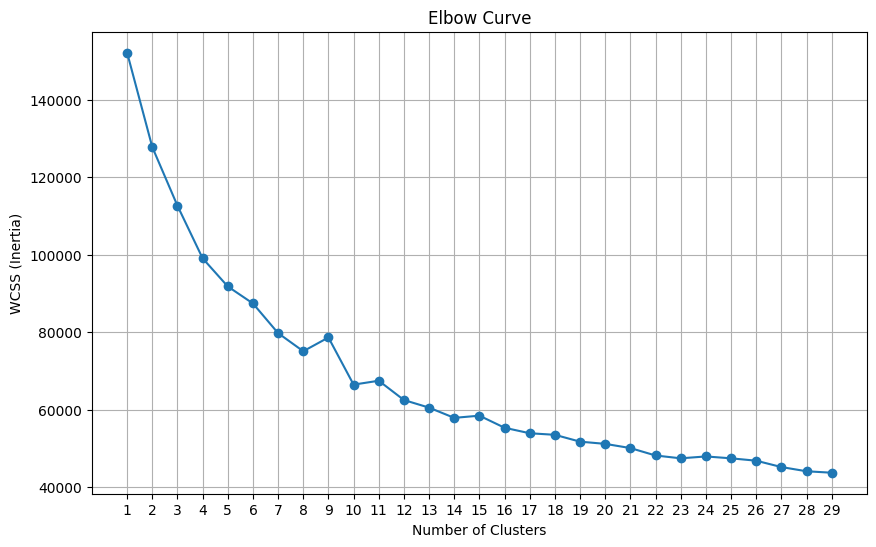

In [ ]:
# Plot the Elbow curve using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), WCSS, marker='o', linestyle='-')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 30))
plt.grid(True)
plt.show()

Apply the optimal KMeans clustering on the PCA-transformed data, and assign cluster labels to each observation. Add a new column named segment to the df_pca DataFrame to store these labels.

In [15]:
# Apply KMeans on PCA-reduced data with the optimal number of clusters based on the elbow method
optimal_clusters = 5
kmeans_pca_optimal = CustomKMeans(n_clusters=optimal_clusters, random_state=42)
kmeans_pca_optimal.fit(df_transformed.values)
cluster_labels = kmeans_pca_optimal.labels_
# Display the first few rows to verify the added cluster labels
print(df_transformed.head())


        PC1       PC2       PC3       PC4       PC5
0 -1.682126  1.076390 -0.488479  0.665515 -0.018224
1 -1.138231 -2.506337 -0.601179 -0.120430 -0.605769
2  0.969630  0.383499 -0.102366  1.209199  2.172463
3 -0.873579 -0.043163 -1.460085  1.151916 -0.295615
4 -1.599344  0.688542 -0.365073  0.990176  0.487012


In [16]:
# Add a new column 'segment' to pca data frame and assign the cluster labels to each observation
df_transformed['segment'] = cluster_labels

 visualize the clustering by plotting the pairwise relationships of the PCA-reduced features, color-coded by the cluster assignments.

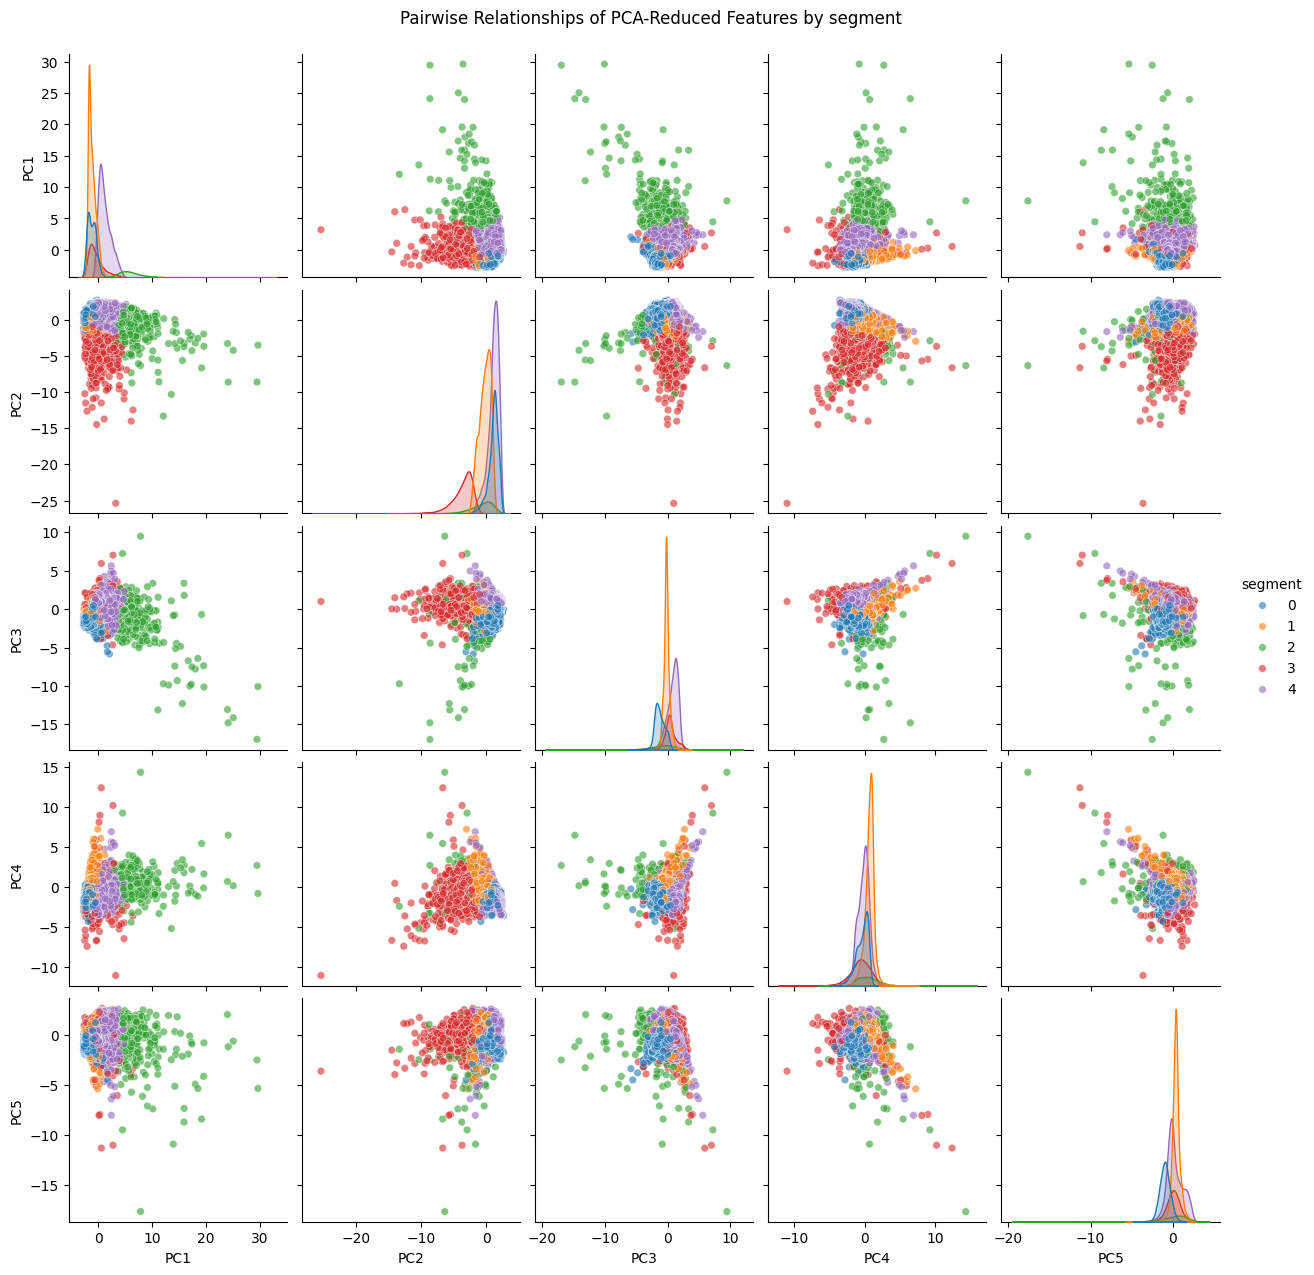

In [17]:
# todo
sns.pairplot(df_transformed, hue='segment', palette='tab10', diag_kind='kde', plot_kws={'alpha':0.6, 's':30})
plt.suptitle("Pairwise Relationships of PCA-Reduced Features by segment", y=1.02)
plt.show()

So, when we employ PCA prior to using K-means we can visually separate almost the entire data set. That was one of the biggest goals of PCA - to reduce the number of variables by combining them into bigger, more meaningful features.

### Hierarchical Clustering
Perform hierarchical clustering on the reduced dataset after PCA. Use complete linkage method.


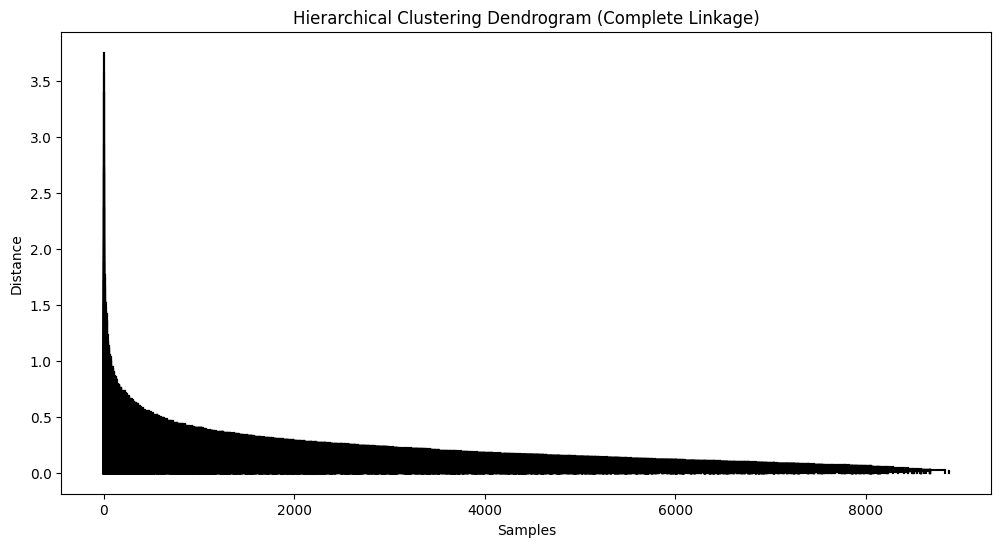

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue

# Function to compute pairwise Euclidean distances
def compute_distance_matrix(X):
    n_samples = X.shape[0]
    distance_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            distance_matrix[i, j] = np.linalg.norm(X[i] - X[j])
            distance_matrix[j, i] = distance_matrix[i, j]  # Symmetric matrix
    return distance_matrix

# Function to perform hierarchical clustering with complete linkage
def hierarchical_clustering_complete_linkage(X):
    distance_matrix = compute_distance_matrix(X)
    n_samples = X.shape[0]
    clusters = [[i] for i in range(n_samples)]
    merge_info = []

    # Use a priority queue to find the closest clusters
    pq = PriorityQueue()
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            pq.put((distance_matrix[i, j], i, j))

    while len(clusters) > 1:
        # Get the closest clusters
        min_dist, c1, c2 = pq.get()

        # If either cluster has been merged already, skip it
        if c1 >= len(clusters) or c2 >= len(clusters):
            continue

        # Merge the two closest clusters
        merge_info.append((c1, c2, min_dist, len(clusters[c1]) + len(clusters[c2])))
        clusters[c1].extend(clusters[c2])
        del clusters[c2]

        # Update distances in the priority queue
        for j in range(len(clusters)):
            if j != c1 and j < len(clusters):
                new_dist = np.max([distance_matrix[p1, p2] for p1 in clusters[c1] for p2 in clusters[j]])
                pq.put((new_dist, c1, j))

    return merge_info

# Visualize the dendrogram
def plot_dendrogram(merge_info, n_samples):
    plt.figure(figsize=(12, 6))

    # Initialize leaves of the dendrogram
    leaves = {i: (i, 0) for i in range(n_samples)}
    current_node = n_samples

    for i, (c1, c2, dist, _) in enumerate(merge_info):
        # Get x-coordinates of the clusters to merge
        x1, h1 = leaves[c1]
        x2, h2 = leaves[c2]

        # Plot vertical lines
        plt.plot([x1, x1], [h1, dist], 'k-')
        plt.plot([x2, x2], [h2, dist], 'k-')

        # Plot horizontal line connecting the two clusters
        plt.plot([x1, x2], [dist, dist], 'k-')

        # Assign x-position of the new cluster and store height
        leaves[current_node] = ((x1 + x2) / 2, dist)
        current_node += 1

    plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

# Apply hierarchical clustering on PCA-transformed data with complete linkage
X_pca = df_transformed.drop(columns='segment').values
merge_info = hierarchical_clustering_complete_linkage(X_pca)

# Plot the dendrogram
plot_dendrogram(merge_info, n_samples=X_pca.shape[0])


"Use scipy.cluster.hierarchy.fcluster to assign clusters from the dendrogram with a specified number of 5 clusters. Then visualize the results using pairplots.

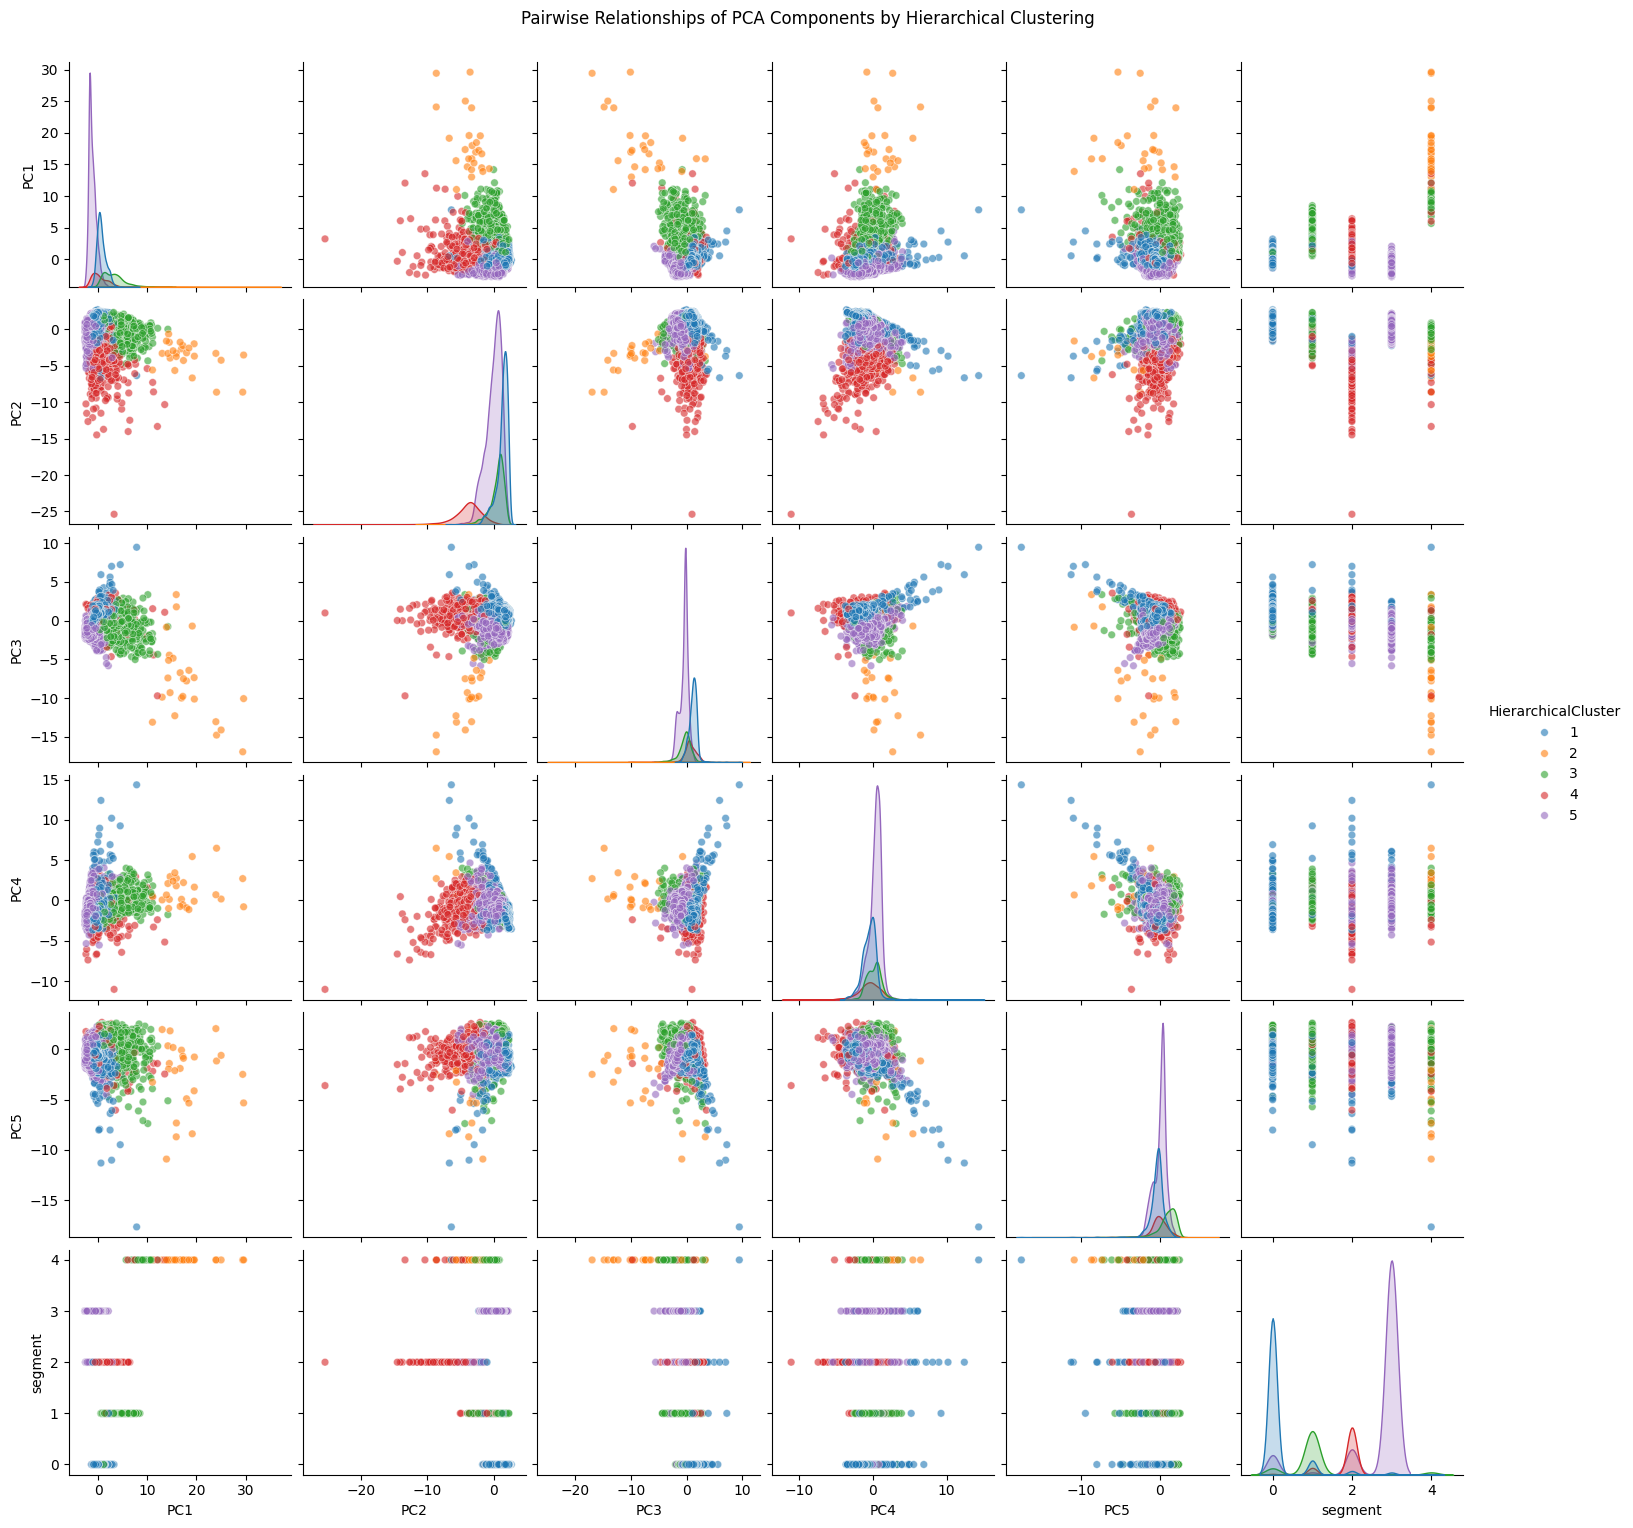

In [ ]:
# Choose threshold and assign clusters

# Assign cluster labels to PCA DataFrame

# Visualize using PCA components
import scipy.cluster.hierarchy as sch

# Step 1: Compute the linkage matrix
linkage_matrix = sch.linkage(df_transformed.drop(columns='segment'), method='ward')

# Step 2: Assign clusters using fcluster with the desired number of clusters (5 in this case)
cluster_labels = sch.fcluster(linkage_matrix, t=5, criterion='maxclust')

# Step 3: Add the cluster labels to the PCA DataFrame for visualization
df_transformed['HierarchicalCluster'] = cluster_labels

# Step 4: Visualize the clusters using pairplot
sns.pairplot(df_transformed, hue='HierarchicalCluster', palette='tab10', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle("Pairwise Relationships of PCA Components by Hierarchical Clustering", y=1.02)
plt.show()